In [453]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datamatrix import DataMatrix, io, SeriesColumn
from datamatrix import series as srs
from datamatrix import convert as cnv

In [454]:
data = pd.read_csv("/Users/arthu/Documents/Marseille/aMU/M1/Stage/data/CTR/Export_pupille_CTR_55_F_77ANS_Benson2_2024-09-04_12-03-20.csv", sep=';', skiprows=21, encoding='latin-1')
data = data.rename(columns={'Time (ms)': 'Time_ms', 'LX (deg)': 'LX_deg', 'LY (deg)': 'LY_deg', 'RX (deg)': 'RX_deg', 'RY (deg)': 'RY_deg',
       'LDX (pix)': 'LDX_pix', 'LDY (pix)': 'LDY_pix', 'RDX (pix)': 'RDX_pix', 'RDY (pix)': 'RDY_pix',
       'Unnamed: 10': 'Unnamed_10'})
data = data.drop(columns = ['Unnamed_10', 'Time_ms'])
data = data.reset_index()

# dm = cnv.from_pandas(df)
# print(dm.Label != np.nan)
print(data.head(5))

   index  LX_deg  LY_deg  RX_deg  RY_deg  LDX_pix  LDY_pix  RDX_pix  RDY_pix  \
0      0   2.309   2.881  -4.843   1.742      267      226      238      202   
1      1   2.309   2.881  -4.844   1.834      267      229      240      204   
2      2   2.365   2.968  -4.844   1.834      270      231      238      197   
3      3   2.369   2.878  -4.843   1.742      270      229      240      202   
4      4   2.309   2.881  -4.844   1.834      270      224      238      197   

          Label  
0  consignes=on  
1           NaN  
2           NaN  
3           NaN  
4           NaN  


In [455]:
s = pd.Series(data.Label)
is_on = pd.Index(data.Label[s.str.extract(r'(^\d+_[A-Za-z]+_[A-Za-z]+_\d+=on+$)').notna()[0]])
is_off = pd.Index(data.Label[s.str.extract(r'(^\d+_[A-Za-z]+_[A-Za-z]+_\d+=off+$)').notna()[0]])

In [456]:
columns = ['LX_deg', 'LY_deg', 'RX_deg', 'RY_deg', 'LDX_pix',
           'LDY_pix', 'RDX_pix', 'RDY_pix', 'category', 'valence']
df = pd.DataFrame(columns=columns)

for i, x in enumerate(is_on):
    a = data.index[data.Label == x][0]
    
    LX = (data.iloc[a:a+1792, :].LX_deg.to_list())
    LY = (data.iloc[a:a+1792, :].LY_deg.to_list())
    RX = (data.iloc[a:a+1792, :].RX_deg.to_list())
    RY = (data.iloc[a:a+1792, :].RY_deg.to_list())
    LDX = (data.iloc[a:a+1792, :].LDX_pix.to_list())
    LDY = (data.iloc[a:a+1792, :].LDY_pix.to_list())
    RDX = (data.iloc[a:a+1792, :].RDX_pix.to_list())
    RDY = (data.iloc[a:a+1792, :].RDY_pix.to_list())

    new_row = pd.DataFrame([{'LX_deg': LX, 'LY_deg': LY, 'RX_deg': RX, 'RY_deg': RY, 'LDX_pix': LDX,
    'LDY_pix': LDY, 'RDX_pix': RDX, 'RDY_pix': RDY, 'category': x.split('_')[1], 'valence': x.split('_')[2]}])
    df = pd.concat([df, new_row], ignore_index=True)

In [470]:
dm = DataMatrix(length=len(df))

for i in df.columns.values:
    two_d_array = np.array(df[i].tolist())
    dm[i] = two_d_array

(array([1., 3., 0., 1., 3., 0., 2., 1., 0., 0., 3., 0., 1., 0., 1., 1., 0.,
        0., 0., 1.]),
 array([291.6 , 294.91, 298.22, 301.53, 304.84, 308.15, 311.46, 314.77,
        318.08, 321.39, 324.7 , 328.01, 331.32, 334.63, 337.94, 341.25,
        344.56, 347.87, 351.18, 354.49, 357.8 ]),
 <BarContainer object of 20 artists>)

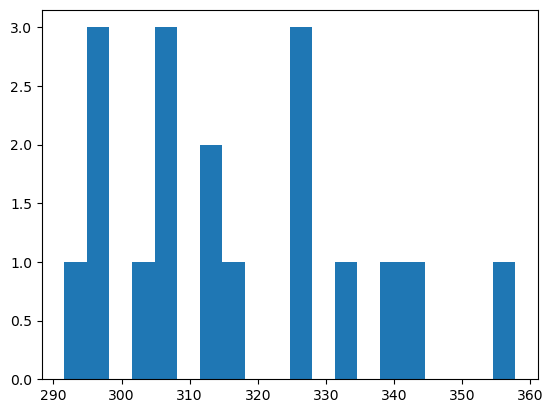

In [458]:
dm.pupil_baseline = srs.reduce_(srs.window(dm.LDX_pix, 0, 5))
plt.hist(dm.pupil_baseline, bins=20)

In [471]:
dm.pupil_RDX_br = srs.blinkreconstruct(dm.RDX_pix, maxdur=120, margin=15, mode='advanced')
dm.pupil_RDX_s = srs.smooth(dm.pupil_RDX_br)
dm.pupil_RDX_blc = srs.baseline(dm.pupil_RDX_s, dm.pupil_RDX_s, 0, 5)
# dm.pupil_LDX_blc = srs.baseline(dm.LDX_pix, dm.LDX_pix, 0, 5)

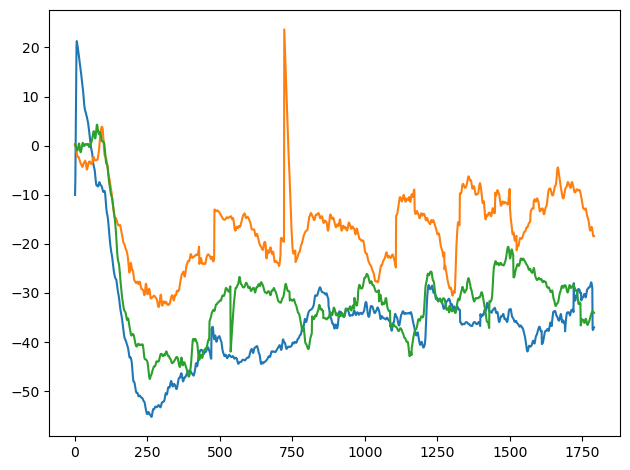

In [473]:
from datamatrix import operations as ops

dmpos, dmneg, dmneu = ops.split(dm.valence, 'positive', 'negative', 'neutre')
dmobj, dmvis = ops.split(dm.category, 'objet', 'visage')
plt.plot(dmpos.pupil_RDX_blc.mean)
plt.plot(dmneg.pupil_RDX_blc.mean)
plt.plot(dmneu.pupil_RDX_blc.mean)
plt.tight_layout()

In [477]:
df.head()

,LX_deg,LY_deg,RX_deg,RY_deg,LDX_pix,LDY_pix,RDX_pix,RDY_pix,category,valence
0,"[4.985, 4.809, 4.813, 4.636, 4.523, 4.11, 4.11...","[3.766, 3.77, 3.681, 3.686, 3.6, 3.612, 3.612,...","[-2.031, -2.031, -2.093, -2.218, -2.468, -2.65...","[1.914, 1.914, 1.918, 1.832, 1.938, 1.857, 1.7...","[299, 294, 292, 290, 283, 284, 286, 284, 283, ...","[258, 252, 262, 263, 265, 258, 263, 263, 261, ...","[259, 265, 261, 265, 260, 249, 246, 249, 249, ...","[233, 235, 231, 235, 235, 233, 228, 236, 234, ...",objet,negative
1,"[11.192, 11.303, 11.303, 11.302, 11.302, 11.30...","[1.857, 2.034, 2.034, 1.948, 1.948, 1.948, 2.0...","[4.372, 4.429, 4.368, 4.425, 4.489, 4.372, 4.5...","[0.08, -0.007, -0.009, -0.096, -0.004, 0.08, -...","[315, 315, 315, 315, 315, 315, 313, 320, 320, ...","[288, 295, 295, 286, 290, 288, 290, 291, 292, ...","[292, 292, 292, 292, 294, 294, 292, 290, 292, ...","[249, 244, 247, 247, 247, 249, 247, 242, 242, ...",visage,positive
2,"[8.464, 8.183, 6.035, 31.819, 8.183, -107.656,...","[-3.507, -9.369, -5.001, -20.283, -9.369, -32....","[-18.738, 11.023, -18.674, -14.846, -47.675, -...","[-15.757, -12.058, -13.798, -12.188, -24.163, ...","[32, 0, 960, 797, 0, 0, 0, 469, 135, 169, 217,...","[43, 0, 435, 208, 0, 0, 0, 237, 27, 70, 76, 11...","[329, 0, 474, 288, 0, 400, 0, 352, 0, 0, 0, 0,...","[154, 0, 192, 211, 0, 176, 0, 254, 0, 0, 0, 0,...",objet,positive
3,"[9.978, 9.92, 10.15, 10.092, 10.208, 10.323, 1...","[5.629, 5.716, 5.81, 5.809, 5.812, 5.815, 5.63...","[2.756, 2.694, 2.633, 2.635, 2.756, 2.751, 2.8...","[2.665, 2.664, 2.663, 2.755, 2.665, 2.48, 2.48...","[304, 290, 301, 293, 292, 297, 294, 292, 290, ...","[266, 268, 272, 268, 268, 272, 268, 266, 266, ...","[268, 277, 275, 277, 270, 272, 272, 276, 272, ...","[224, 226, 226, 226, 226, 228, 226, 226, 228, ...",visage,neutre
4,"[4.936, 4.553, 3.8, 3.08, 2.921, 2.921, 2.954,...","[8.521, 8.535, 8.476, 8.238, 8.065, 8.065, 7.8...","[-1.661, -2.106, -2.62, -3.509, -3.831, -3.831...","[4.8, 4.726, 4.754, 4.621, 4.644, 4.644, 4.554...","[302, 304, 300, 302, 304, 302, 302, 302, 302, ...","[266, 268, 261, 256, 256, 258, 260, 267, 256, ...","[279, 272, 275, 284, 281, 281, 276, 281, 278, ...","[240, 238, 240, 238, 240, 240, 236, 236, 236, ...",visage,negative


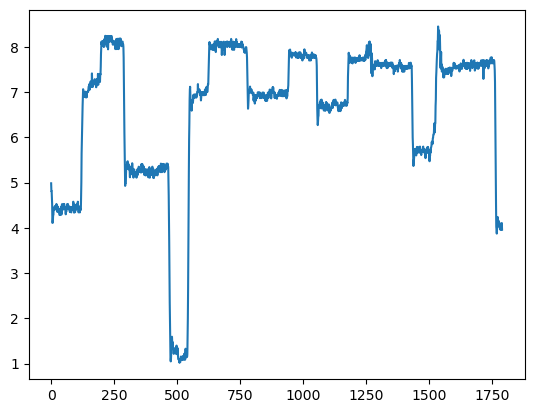

In [488]:
dm.LX_br = srs.blinkreconstruct(dm.LX_deg, maxdur=120, margin=15, mode='advanced')
plt.plot(dm.LX_deg[0])